# Scripts de extracción de datos
- Osvaldo Ceballos O. , Andrés Jimenez B.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

import os
cwd= os.getcwd()
print (cwd)

C:\Users\oaceb\PycharmProjects\AnalisisLogisitca\src


# 1.- Datos aduanas

### 2.1 Fuente Datos Abiertos Gobierno de Chile (Datos.gov.cl)
https://datos.gob.cl/organization/servicio_nacional_de_aduanas

In [2]:
!pip install ckanapi requests openpyxl

In [3]:
import urllib
from ckanapi import RemoteCKAN
import requests
import pandas as pd
import numpy as np

In [9]:
# URL del portal CKAN
ckan_url = 'https://datos.gob.cl/'

# Conexión al portal CKAN
ckan = RemoteCKAN(ckan_url)

# Realizar una búsqueda de datasets
query = 'Registros de Importación 2020'  #@param
results = ckan.action.package_search(q=query)

# Registros de Importación 2018: c2f1008d-b84f-49cd-ba27-16cb7e842f38
# Registro de Importación 2023: d1a42e81-b874-4964-9b3d-74dc0f813eae
# Registro de Importación 2024: 096c3946-657e-420f-ae74-2337c00b5ba2
# Registro de Importación 2025: 385fb63b-c898-4690-aa3f-d59d933fc30c

# Mostrar nombres y descripciones de los primeros datasets encontrados
for dataset in results['results']:
    print(f"Nombre: {dataset['title']}")
    print(f"Descripción: {dataset['notes']}")
    print(f"Id: {dataset['id']}\n")

Nombre: Registro de Importación 2020
Descripción: Muestra el registro de ítems correspondientes a las declaraciones de ingreso (DIN) del año 2020. Registros mensuales. Formato comprimido  winrar. 
Para poder hacer uso del archivo, es necesaria la descarga de todas las partes de un mismo mes.
Id: 6ed59525-1ff2-44d9-a26f-0e9078ca45d0

Nombre: Registros de Importación 2010
Descripción: Muestra el registro de ítems correspondientes a las declaraciones de ingreso (DIN) del año 2010. Registros mensuales.
Id: ed97ca95-b74e-4182-850a-d23e515d3b23

Nombre: Registros de Importación 2014
Descripción: Muestra el registro de ítems correspondientes a las declaraciones de ingreso (DIN) del año 2014. Registros mensuales.
Id: 097803f9-333b-4cc4-a07a-a1d0bc15fbdd

Nombre: Registros de Importación 2015
Descripción: Muestra el registro de ítems correspondientes a las declaraciones de ingreso (DIN) del año 2015.
Registros mensuales.

Id: da62712a-eecd-451c-9015-fd8803a45407

Nombre: Registros de Importació

In [13]:
import os
import requests
from urllib.parse import urlparse, unquote

data_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data","aduanas"))
os.makedirs(data_dir, exist_ok=True)

for dataset in results['results']:
    dataset_id = dataset['id']

    # Obtener detalles del dataset
    dataset_sub = ckan.action.package_show(id=dataset_id)

    # Mostrar información relevante
    print(f"Nombre: {dataset['title']}")
    print(f"Descripción: {dataset['notes']}")
    print(f"Recursos disponibles:")

    for resource in dataset_sub['resources']:
        resource_url = resource.get('url')
        resource_name = resource.get('name') or 'recurso'
        print(f"- {resource_name}: {resource.get('format')} ({resource_url})")

        if not resource_url:
            continue

        parsed_url = urlparse(resource_url)
        filename = os.path.basename(parsed_url.path) or f"{resource_name}"
        filename = unquote(filename)
        file_path = os.path.join(data_dir, filename)

        response = requests.get(resource_url, stream=True, timeout=120)
        response.raise_for_status()

        with open(file_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)



Nombre: Registro de Exportaciones 2026
Descripción: Muestra el registro de ítems correspondientes a los Documentos únicos de Salida (DUS) del año 2026. Registros mensuales. Formato comprimido WinRar.
Recursos disponibles:
- Metadata Exportaciones: xlsx (https://datos.gob.cl/dataset/f6a643e7-a2e4-48e4-866e-732c7ceb51f3/resource/e0a25239-af2f-49be-afc3-44be524d6e4e/download/descripcion-y-estructura-de-datos-.xlsx)
- Exportaciones enero 2026: rar (https://datos.gob.cl/dataset/f6a643e7-a2e4-48e4-866e-732c7ceb51f3/resource/e8075003-9f64-4e3a-aa7e-f689a7e056eb/download/exportaciones-enero-2026.rar)
- Exportaciones enero 2026 – Bultos: rar (https://datos.gob.cl/dataset/f6a643e7-a2e4-48e4-866e-732c7ceb51f3/resource/6dd1316e-fe99-4a62-80c2-d838dcb3695a/download/exportaciones-enero-2026-bultos.rar)
- Exportaciones enero 2026 – Documentos de Transporte: rar (https://datos.gob.cl/dataset/f6a643e7-a2e4-48e4-866e-732c7ceb51f3/resource/f15ca5c2-ee96-4d47-be9b-61ca677ab4d7/download/exportaciones-enero

Esta parte se ejecuta para extraer los archivos .rar y consolidar

In [ ]:
#Para colab
#!apt-get install unrar #linux



In [2]:
import os
import tempfile
from pathlib import Path
import pandas as pd
import rarfile

In [6]:
aduanas_dir = Path(os.path.abspath(os.path.join(os.getcwd(), "..", "data", "aduanas")))
extract_dir = Path(tempfile.mkdtemp(prefix="extracted_files"))

# Specify the full path to the unrar.exe file
rarfile.UNRAR_TOOL = r"C:\Program Files\WinRAR\UnRAR.exe" #comentar si se trabaja con linux/unix

df_list = []

part01_files = sorted(aduanas_dir.glob("*.part01.rar"))

for rar_file in part01_files:
    with rarfile.RarFile(rar_file) as rar_archive:
        rar_archive.extractall(path=extract_dir)

txt_files = sorted(extract_dir.rglob("*.txt"))

for txt_file in txt_files:
    try:
        df_tmp = pd.read_csv(txt_file, sep=";", low_memory=False, encoding="latin-1")
    except Exception:
        df_tmp = pd.read_csv(txt_file, sep=",", low_memory=False, encoding="latin-1")
    df_tmp["archivo_origen"] = txt_file.name
    df_list.append(df_tmp)
    txt_file.unlink(missing_ok=True)

aduanas_df = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

aduanas_df.to_csv(aduanas_dir / "aduanas_df.csv", sep= ';', index=False, encoding="utf-8")


ParserError: Error tokenizing data. C error: Expected 14 fields in line 65, saw 15


### 2.2 Banco Central de Chile
https://si3.bcentral.cl/Siete/es/Siete/API?respuesta=

In [ ]:
!pip install bcchapi

In [9]:
import bcchapi

# Incluyendo credenciales explícitamente
# O bien llamando a un archivo
siete = bcchapi.Siete(file="credenciales_bcentral_api.txt")

In [10]:
siete.buscar("M1")

# "F021.M1.PRO.N.CLP.0.M" # Agregados monetarios nominales saldos, M1 (Mil...

# "F033.IBI.FLU.N.CLP.2018.0.T" # Gasto del producto interno bruto, a precios corrientes, series empalmadas, referencia 2018 (miles de millones de pesos) Importación Bienes

# "F049.OCU.PMT.INE4.34.M" # Ocupación por rama de actividad económica, mensual, INE (promedios móviles trimestrales, miles de personas)

# F034.NTEA.FLU.BCCH.Z.INM.M  # Actividades inmobiliarias Número total de empresas que declaran ventas, por actividad económica (Cantidad)




,seriesId,frequencyCode,spanishTitle,englishTitle,firstObservation,lastObservation,updatedAt,createdAt
0,F021.M1.PPIB18.N.CLP.0.T,QUARTERLY,"M1/PIB (M1 como porcentaje del PIB, últimos 12...","M1/GDP (M1 as percentage of GDP, last 12 month...",1996-10-01,2025-10-01,2026-03-18,2026-03-18
1,F021.M1.STO.N.CLP.0.D,DAILY,Base monetaria y agregados monetarios privados...,Components of M1 (billions of pesos). M1,2011-01-03,2026-02-27,2026-03-09,2026-03-09
2,F021.M1.STS.N.CLP.0.D,DAILY,Base monetaria y agregados monetarios privados...,Base monetaria y agregados monetarios privados...,1996-01-07,2026-03-23,2026-03-31,2026-03-31
3,F021.M1.PRO.N.CLP.5.M,MONTHLY,M1 | Agregados monetarios y sus componentes – ...,M1 | Monetary aggregates and their components ...,1965-12-01,2026-02-01,2026-03-09,2026-03-09
4,F021.M1.PRO.R.P96R23.5.M,MONTHLY,"M1 | Agregados monetarios – promedios reales, ...","M1 | Monetary aggregates - real averages, base...",1986-01-01,2026-02-01,2026-03-09,2026-03-09
5,F021.M1.PRO.R.P96R23.6.M,MONTHLY,M1 desestacionalizado | Agregados monetarios –...,Seasonally adjusted M1 | Monetary aggregates -...,1986-01-01,2026-02-01,2026-03-09,2026-03-09
6,F021.M1.STO.N.CLP.5.M,MONTHLY,M1 | Agregados monetarios y sus componentes – ...,M1 | Monetary aggregates and their components ...,1986-01-01,2026-02-01,2026-03-09,2026-03-09
7,F021.M1.STO.N.CLP.6.M,MONTHLY,M1 desestacionalizado | Agregados monetarios y...,Seasonally adjusted M1 | Monetary aggregates a...,1986-01-01,2026-02-01,2026-03-09,2026-03-09
8,F021.M1.STO.N.CLP.HIST.M,MONTHLY,"Agregados monetarios nominales promedios, M1, ...",Base monetaria y agregados monetarios privados...,1965-12-01,2014-12-01,2015-05-28,2015-02-09
9,F021.M1.STO.R.P96.0.M,MONTHLY,M1 | Agregados monetarios histórico - promedio...,M1 | Historical monetary aggregates - real ave...,1986-01-01,2023-12-01,2024-11-08,2024-01-08


In [22]:
series_bc = siete.cuadro(
  series=["F032.IMC.IND.Z.Z.EP18.Z.Z.0.M",
          "G073.IPC.IND.2018.M",
          "F021.M1.STO.N.CLP.5.M",
          "F033.IBI.FLU.N.CLP.2018.0.T" ,
          "F049.OCU.PMT.INE4.34.M",
          "F034.NTEA.FLU.BCCH.Z.INM.M"],
  nombres = ["imacec", "ipc","M1", "PIBimportBienes", "OcupINE", 'InmobiliariasCVenta' ],
  desde="2010-01-01",
  hasta="2026-04-01",
  #variacion=12,
  frecuencia="M",
  observado={"imacec":"mean", "ipc":"mean", "M1":"mean", "PIBimportBienes":"mean", "OcupINE":"mean", "InmobiliariasCVenta":'mean'}
)

C:\Users\oaceb\anaconda3\Lib\site-packages\bcchapi\siete.py:132: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled = df.resample(frequency, **resample_kw)


In [21]:
#series_bc =  pd.read_csv('../data/bcentral/series_bc.csv', sep=';', encoding='utf-8')

In [23]:
series_bc = series_bc.fillna(0)
series_bc.head(50)

,imacec,ipc,M1,PIBimportBienes,OcupINE,InmobiliariasCVenta
2010-01-31,72.478647,76.458780,14549.330000,6536.674672,0.000000,0.0
2010-02-28,69.784256,76.673627,14557.100000,0.000000,0.000000,0.0
2010-03-31,75.714061,76.738097,14743.660000,0.000000,0.000000,0.0
2010-04-30,77.836154,77.092780,15710.880000,7338.711581,0.000000,0.0
2010-05-31,77.265080,77.370183,16219.970000,0.000000,0.000000,0.0
2010-06-30,76.186444,77.370465,15954.800000,0.000000,0.000000,0.0
2010-07-31,74.112635,77.867485,15583.520000,8007.916622,0.000000,0.0
2010-08-31,77.296543,77.790935,15505.630000,0.000000,0.000000,0.0
2010-09-30,75.050155,78.102046,15773.930000,0.000000,0.000000,0.0
2010-10-31,80.061679,78.178624,15867.950000,8025.803794,0.000000,0.0


In [25]:
series_bc['PIBimportBienes'] = series_bc['PIBimportBienes'].replace(0, np.nan)
series_bc['PIBimportBienes'] = series_bc['PIBimportBienes']\
    .resample('M').asfreq()\
    .interpolate(method='cubic')
series_bc.head()

C:\Users\oaceb\AppData\Local\Temp\ipykernel_17048\3785871303.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').asfreq()\


,imacec,ipc,M1,PIBimportBienes,OcupINE,InmobiliariasCVenta
2010-01-31,72.478647,76.458780,14549.33,6536.674672,0.0,0.0
2010-02-28,69.784256,76.673627,14557.10,6755.516893,0.0,0.0
2010-03-31,75.714061,76.738097,14743.66,7044.136199,0.0,0.0
2010-04-30,77.836154,77.092780,15710.88,7338.711581,0.0,0.0
2010-05-31,77.265080,77.370183,16219.97,7625.673587,0.0,0.0


In [26]:
series_bc.index = pd.to_datetime(series_bc.index).to_period('M')


In [27]:
series_bc.to_csv('../data/bcentral/series_bc.csv', sep=';', index=True, encoding='utf-8')

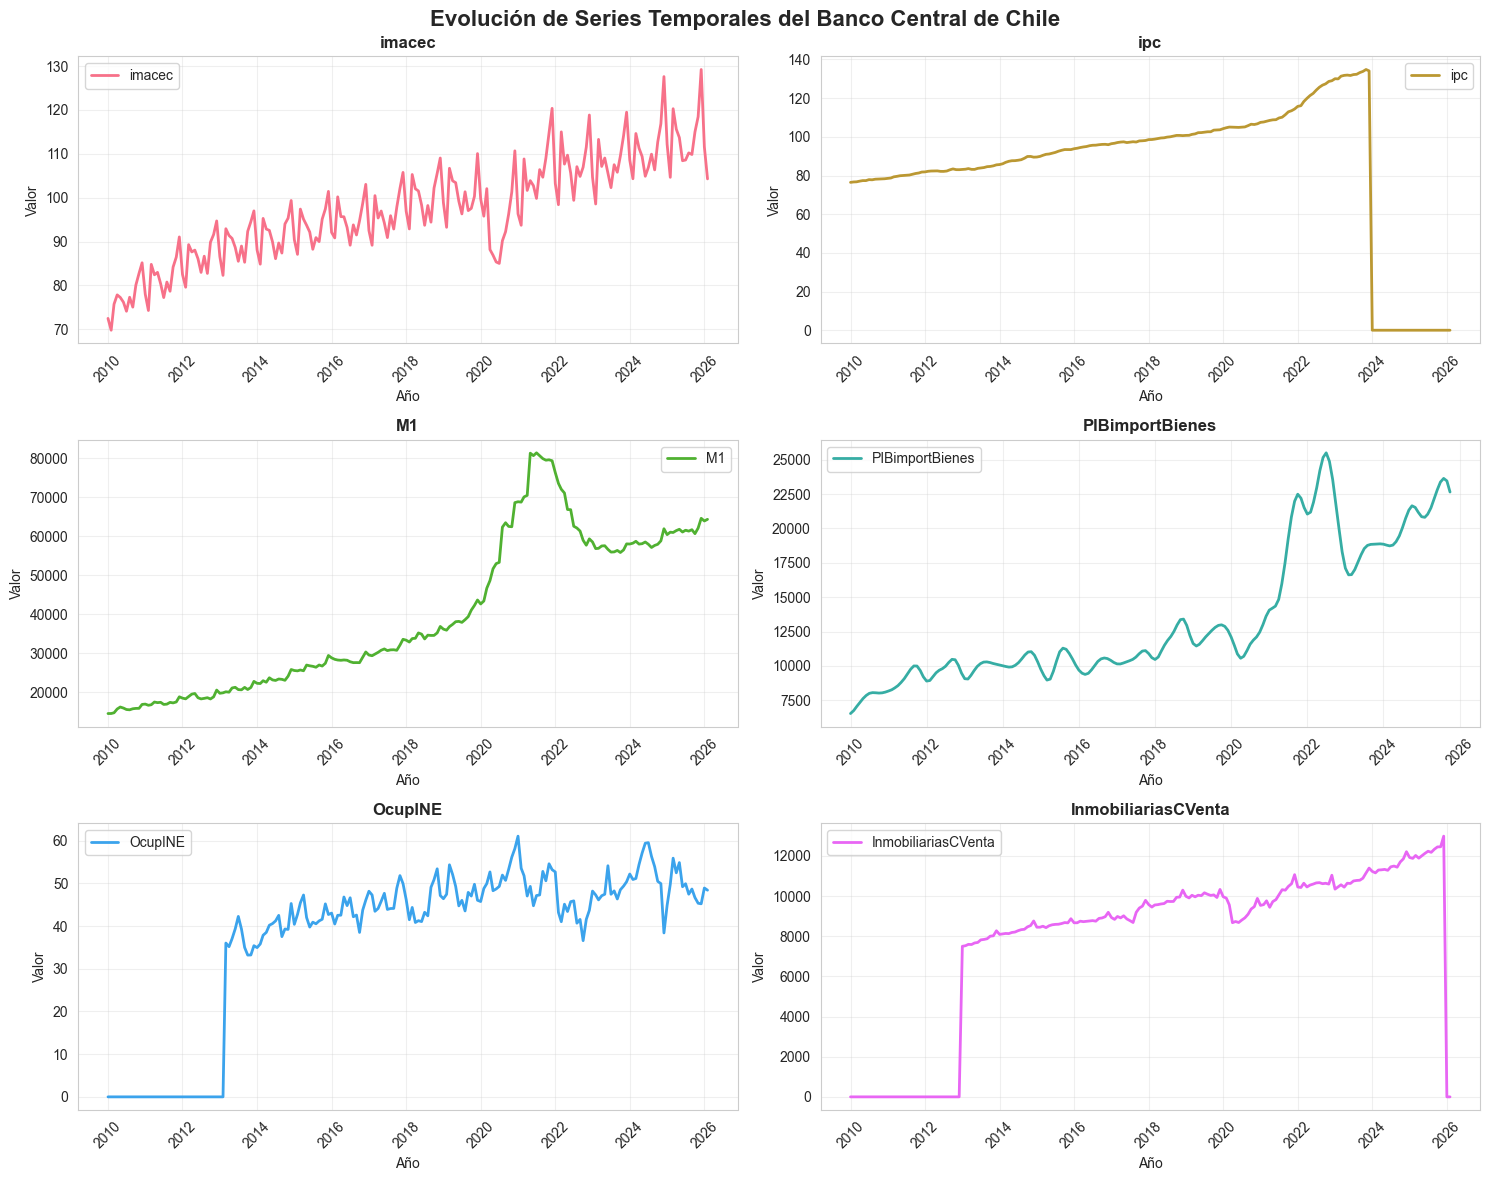

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de seaborn
sns.set_style("whitegrid")

# Crear figura con subplots para cada serie
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Evolución de Series Temporales del Banco Central de Chile', fontsize=16, fontweight='bold')

# Aplanar los ejes para facilitar la iteración
axes = axes.flatten()

# Colores para cada serie
colors = sns.color_palette("husl", len(series_bc.columns))

# Plotear cada serie en un subplot
for idx, column in enumerate(series_bc.columns):
    ax = axes[idx]

    # Convertir el índice Period a timestamp para el plot
    series_bc_plot = series_bc.copy()
    series_bc_plot.index = series_bc_plot.index.to_timestamp()

    # Plotear la serie
    ax.plot(series_bc_plot.index, series_bc_plot[column],
            color=colors[idx], linewidth=2, label=column)

    # Configurar el subplot
    ax.set_title(column, fontsize=12, fontweight='bold')
    ax.set_xlabel('Año', fontsize=10)
    ax.set_ylabel('Valor', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

# Ajustar el layout
plt.tight_layout()
plt.show()

# Precios de los Combustibles - CNE
http://energiaabierta.cl/categorias-estadistica/hidrocarburos/?_sft_etiquetas-estadistica=precio

In [ ]:
import pandas as pd

# Leer un archivo Excel especificando la hoja
df = pd.read_excel('../data/ruta_archivo.xlsx', sheet_name='NombreHoja', header=1)

# Mostrar la primera fila
df.head(1)


In [4]:
import bz2
from io import TextIOWrapper

cne_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "cne"))
bz2_files = sorted(
    [
        os.path.join(cne_dir, f)
        for f in os.listdir(cne_dir)
        if f.lower().endswith(".csv.bz2") or f.lower().endswith(".bz2")
    ]
)

cne_df_list = []
for file_path in bz2_files:
    with bz2.open(file_path, "rt", encoding="utf-8", errors="replace") as f:
        df_tmp = pd.read_csv(f, low_memory=False, sep = ';', decimal=',', encoding="latin-1")
    df_tmp["archivo_origen"] = os.path.basename(file_path)
    cne_df_list.append(df_tmp)

cne_df = pd.concat(cne_df_list, ignore_index=True) if cne_df_list else pd.DataFrame()

cne_df.head()


,id,razon_social,distribuidor,direccion_calle,direccion_numero,comuna,region,precio,fecha_actualizacion,combustible,latitud,longitud,archivo_origen,"codigo,razon_social,distribuidor,direccion,latitud,longitud,nom_comuna,nom_region,combustible,precio,unidad_cobro,atencion,fecha_actualizacion,hora_actualizacion,es_electrolinera,es_gasolinera"
0,co1312002,Sociedad Herrera Bravo Ltda,COPEC,Avenida Irarrázaval,5277,Ñuñoa,Metropolitana,759.0,2012-01-01,Gasolina 93,"-33,4540062109273","-70,57525992393493",2012.csv.bz2,NaN
1,pb630302,Distribuidora Dagnino Giacobbe y Cía. Ltda. 7...,Sin Bandera,Camino a Codegua Km,01,Chimbarongo,Gral. Bernardo O'Higgins,612.0,2012-12-13,Petroleo Diesel,"-34,71739081954427","-71,02941691875458",2012.csv.bz2,NaN
2,co120501,SOCIEDAD COMERCIAL IBAï¿½EZ Y NEGRON LTDA.,COPEC,"PANAMERICANA NORTE KM 1750, EX S. V",0,Pozo Almonte,Tarapacá,777.0,2012-12-06,Gasolina 95,"-21,09225805724834","-69,5928230881691",2012.csv.bz2,NaN
3,te1312301,Gilberto Zamorano Vega,SHELL,Holanda,2808,Providencia,Metropolitana,790.0,2012-12-06,Gasolina 97,"-33,44420837761395","-70,59720039367676",2012.csv.bz2,NaN
4,co1313201,PATRICIO REYES INFANTE Y CIA LTDA,COPEC,Av. Vitacura,6380,Vitacura,Metropolitana,873.0,2012-09-06,Gasolina 97,"-33,38974288164123","-70,57051241397858",2012.csv.bz2,NaN


In [5]:
cne_df.to_csv(os.path.join(cne_dir,'cne_df.csv'),
              sep = ';',
              index = False,
              encoding='utf-8')